# Outlier-removed GPR

- It was noticed in GPR 6 that the training data had occasional clear outliers.
- When the outliers are present the model performance degraded considerably.
- Here we will remove the outliers and see if the performance improves.
- Next step after: model comparison.

In [2]:
# Importing and data hopo hopo
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl

from astropy.time import Time
from astropy.timeseries import LombScargle

from scipy.signal import find_peaks
from scipy.optimize import curve_fit, minimize

import celerite2
from celerite2 import terms

from prettytable import PrettyTable

import sys
from pathlib import Path

sys.path.append(str(Path('../..').resolve()))

from helpers.LSP_peaks import fit_peaks, set_period_axes
from helpers.df_ops import prepare_df, split_df
from helpers.priors import find_classify_signals, get_priors


# Individual stars
raw_HD81809 = pd.read_csv(r"../../Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
raw_HD160346 = pd.read_csv(r"../../Data/benchmark/HD160346_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
raw_HD201091 =pd.read_csv(r"../../Data/benchmark/HD201091_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)

data_HD81809 = prepare_df(raw_HD81809)
data_HD160346 = prepare_df(raw_HD160346)
data_HD201091 = prepare_df(raw_HD201091)

train_HD81809,  valid_HD81809,  test_HD81809  = split_df(data_HD81809)
train_HD160346, valid_HD160346, test_HD160346 = split_df(data_HD160346)
train_HD201091, valid_HD201091, test_HD201091 = split_df(data_HD201091)


C:\Users\Joey\AppData\Local\Temp\ipykernel_40808\2370008255.py:29: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  raw_HD81809 = pd.read_csv(r"../../Data/benchmark/HD81809_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
C:\Users\Joey\AppData\Local\Temp\ipykernel_40808\2370008255.py:30: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support regex separators (separators > 1 char and different from '\s+' are interpreted as regex); you can avoid this warning by specifying engine='python'.
  raw_HD160346 = pd.read_csv(r"../../Data/benchmark/HD160346_Mt_wilson_data.txt", sep='\s',skip_blank_lines=True)
C:\Users\Joey\AppData\Local\Temp\ipykernel_40808\2370008255.py:31: ParserWarning: Falling back to the 'python' engine because the 'c' engine does not support rege

In [3]:
def set_params(log_params, k, gp):
    # k = len(log_params) // 3
    params = np.exp(log_params)
    sigmas = params[0:k]
    rhos = params[k:2*k]
    qs = params[2*k::]
    
    gp.kernel = terms.SHOTerm(sigma=sigmas[0], rho=rhos[0], Q=qs[0])
    for k_idx in range(1,k):
        gp.kernel += terms.SHOTerm(sigma=sigmas[k_idx], rho=rhos[k_idx], Q=qs[k_idx])
    return gp

def NLL(log_params, gp, k, y):
    '''
    Calculates the NLL of a set of parameters for a local gp
    '''
    gp = set_params(log_params, k, gp)
    gp.recompute(quiet=True)
    return -gp.log_likelihood(y)

In [4]:
def clean_df(train_df, tol = 3, plot = True, verbose = True):
    '''
    This uses a median absolute deviance filter to remove any crazy outliers in the training data.

    Returns a df with the outliers removed.
    If plot, plots the removed values.
    If verbose, states number of removed values.
    '''
    med = train_df['sind'].median()
    mad = (train_df['sind'] - med).abs().median()
    cleaned_train_df = train_df[(train_df['sind'] - med).abs() < tol * mad]

    if verbose:
        l1 = len(train_df)
        l2 = len(cleaned_train_df)
        print(f"Removed {l1 - l2} datapoints that were deemed ourliers by tolerance in sind of {tol} times MAD.")
    
    if plot:
        fig, ax =plt.subplots(figsize=(20,5))
        ax.scatter(train_HD201091['day'], train_HD201091['sind'], 
           s=10, label='Removed points', alpha=0.5, color='red')
        ax.scatter(cleaned_train_df['day'], cleaned_train_df['sind'], 
                s=10, label='Remaining points', alpha=0.8, color='blue')
        ax.axhline((tol * mad)+med, label = "Threshold", color = 'orange', linestyle = "--")
        ax.legend()
        ax.set_xlabel("Days")
        ax.set_ylabel("SInd")
        plt.tight_layout()
        plt.show()
        

    return cleaned_train_df

Removed 19 datapoints that were deemed ourliers by tolerance in sind of 4 times MAD.


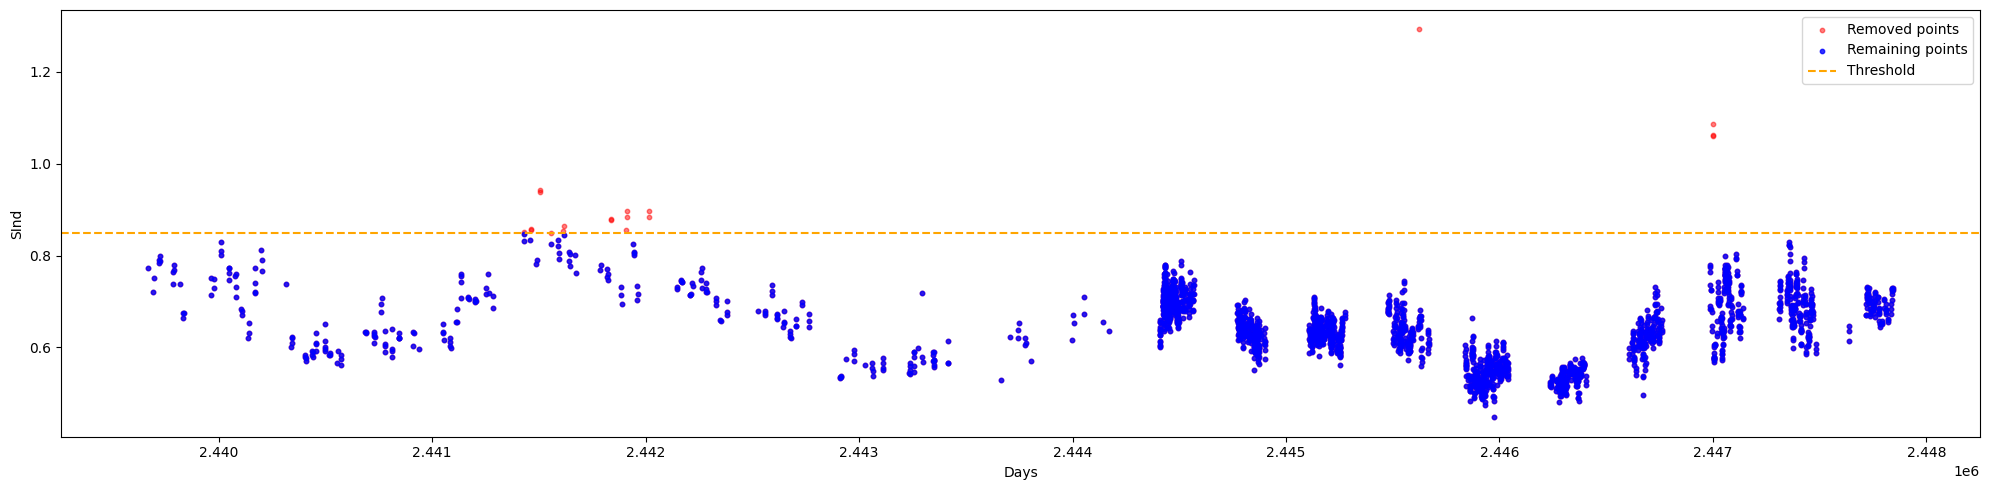

In [5]:
cleaned = clean_df(train_HD201091, tol = 4)
train_HD201091 = cleaned

C:\Users\Joey\Desktop\Cambridge\Work\Thesis\helpers\LSP_peaks.py:173: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  data_timeframe = t[-1] - t[0]


In iteration 0, period at 2699.29 days was accepted.
In iteration 1, period at 12161.99 days was accepted.
Peak at period 1373.24 days was identified to be an alias of 2699.29 days at mult 0.50 by tolerance 0.02.
In iteration 2, period at 540.67 days was accepted.
In iteration 3, period at 1420.33 days was accepted.
In iteration 4, period at 36.97 days was accepted.
In iteration 5, period at 40.62 days was accepted.
Peak at period 176.40 days was identified to be an alias of 540.67 days at mult 0.33 by tolerance 0.02.
Peak at period 39.89 days was identified to be an alias of 40.62 days at mult 1.00 by tolerance 0.02.
Peak at period 119.46 days was identified to be an alias of 40.62 days at mult 3.00 by tolerance 0.02.
Peak at period 41.71 days was identified to be an alias of 40.62 days at mult 1.00 by tolerance 0.03.
Peak at period 18.72 days was identified to be an alias of 36.97 days at mult 0.50 by tolerance 0.01.
In iteration 6, period at 253.41 days was accepted.
Peak at period 

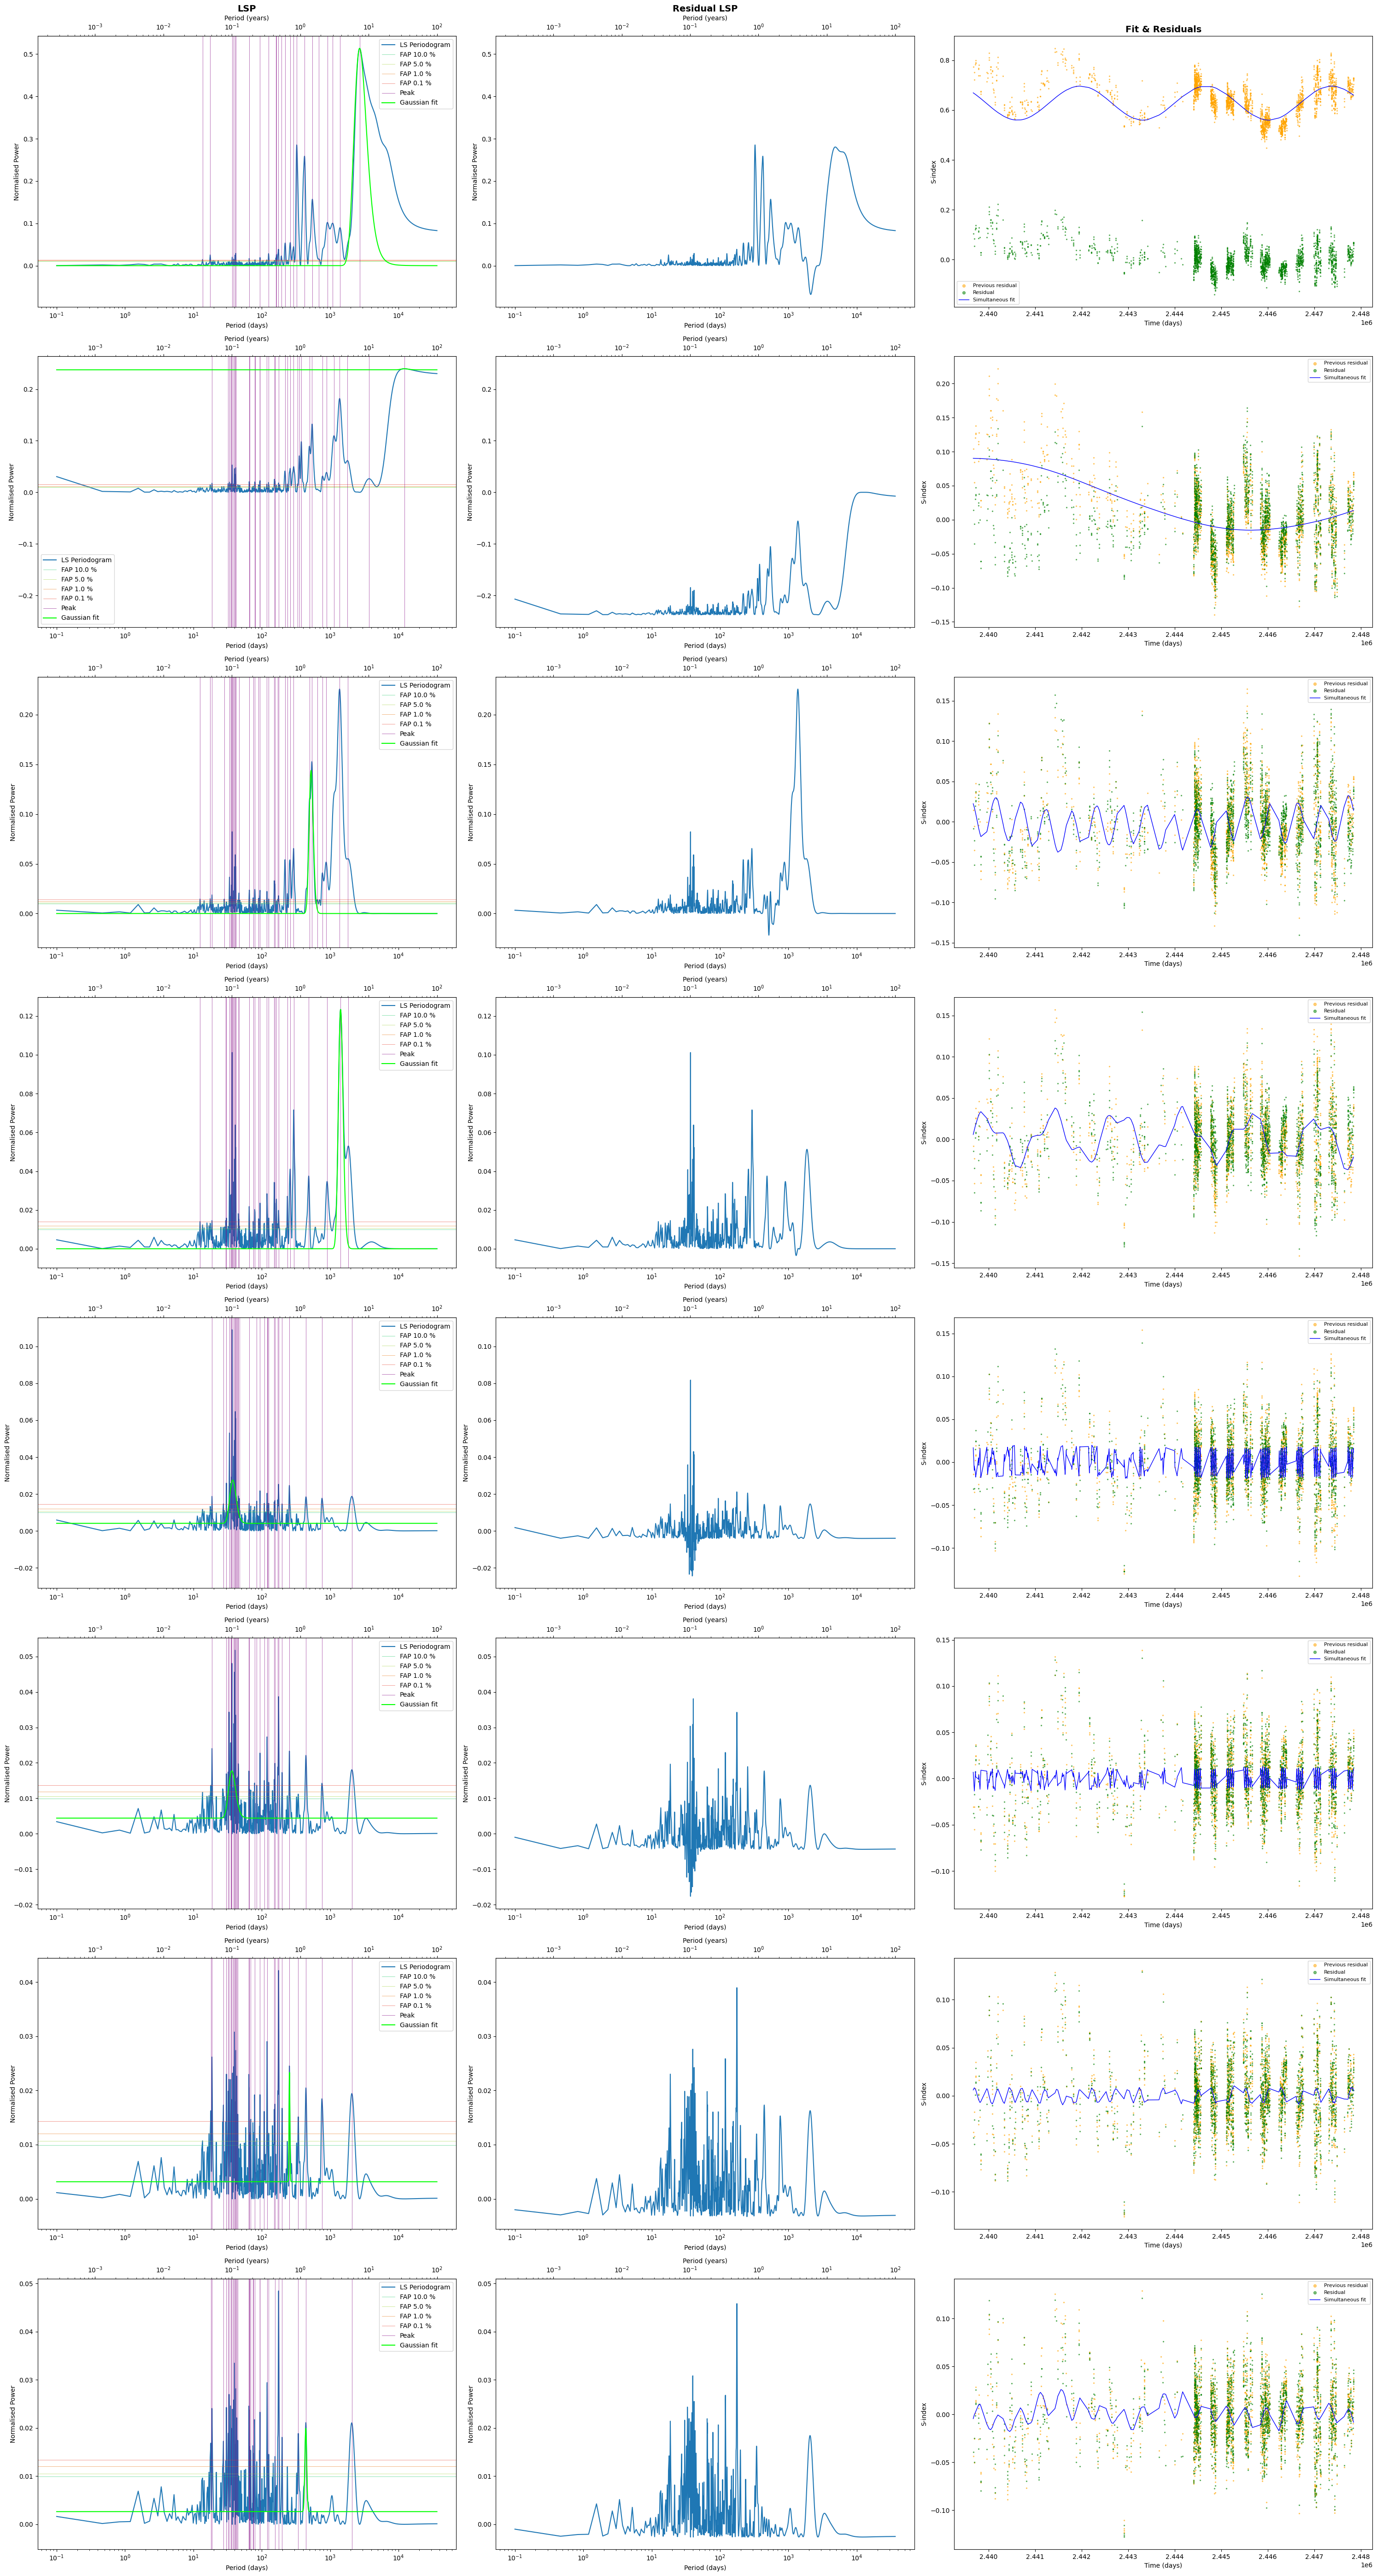

Accepted periods and their heights
+----------+-------+--------+--------------+
|   Days   | Years | Height |     SNR      |
+----------+-------+--------+--------------+
| 2699.29  |  7.40 | 0.5135 |   23879.71   |
| 12161.99 | 33.32 | 0.2398 | 126025690.69 |
|  540.67  |  1.48 | 0.1527 |    11.32     |
| 1420.33  |  3.89 | 0.1234 |    930.14    |
|  36.97   |  0.10 | 0.1090 |    11.69     |
|  40.62   |  0.11 | 0.0518 |     7.77     |
|  253.41  |  0.69 | 0.0245 |     8.22     |
|  441.39  |  1.21 | 0.0211 |    13.02     |
+----------+-------+--------+--------------+


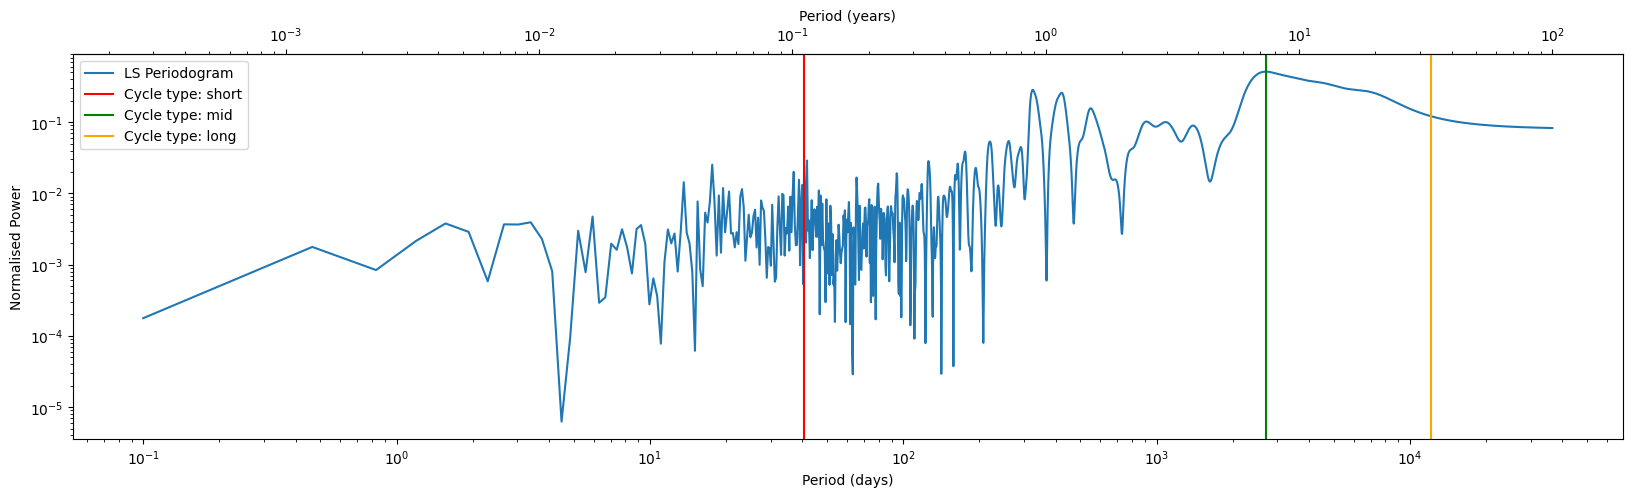

Classified Signals
+------------+------------+-------------+
| Cycle Type | Prior Days | Prior Years |
+------------+------------+-------------+
|   Short    |   40.62    |     0.11    |
|    Mid     |  2699.29   |     7.40    |
|    Long    |  12161.99  |    33.32    |
+------------+------------+-------------+
+------------+------------+-------------+--------+
| Cycle Type | Prior Days | Prior Years | Source |
+------------+------------+-------------+--------+
|   Short    |   40.62    |     0.11    | found  |
|    Mid     |  2699.29   |     7.40    | found  |
|    Long    |  12161.99  |    33.32    | found  |
+------------+------------+-------------+--------+


In [6]:
classified_signal_data = find_classify_signals(train_HD201091)
priors = get_priors(classified_signal_data, 'K') 

True CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
For k = 2
+--------+------+------------+-------------+
| sigma  |  Q   | rho (days) | rho (years) |
+--------+------+------------+-------------+
| 0.0274 | 4.66 |   35.78    |     0.10    |
| 0.0686 | 0.50 |  1289.01   |     3.53    |
+--------+------+------------+-------------+


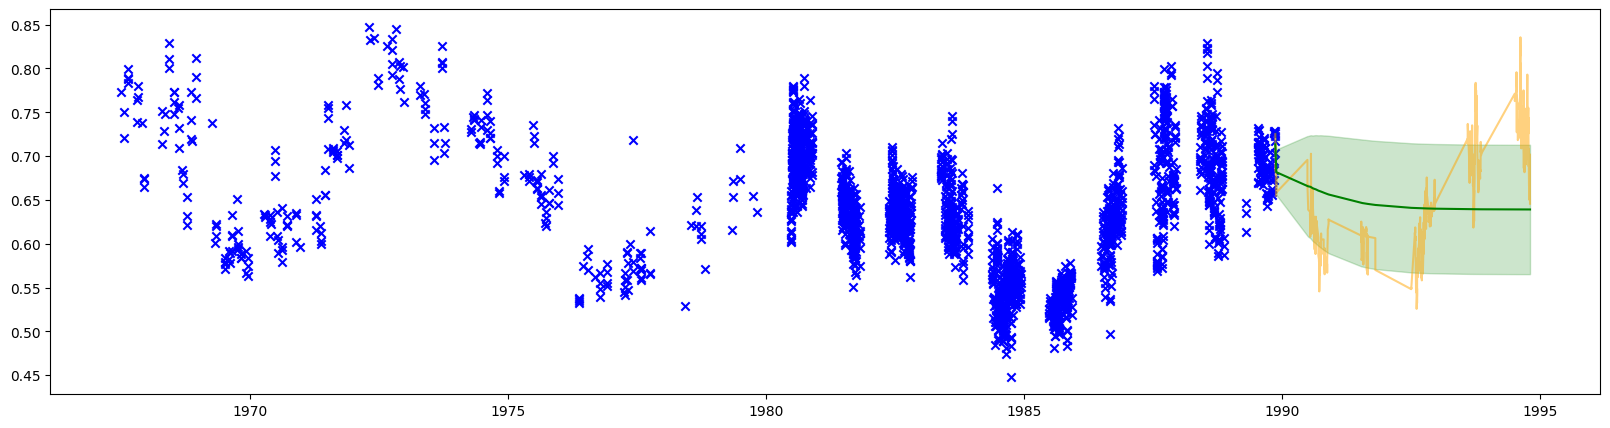

In [8]:

train_df = train_HD201091
k = 2
error_percent = 5
train_yerr = train_df['sind'] * error_percent / 100
verbose = True

# Some key stats
mean_train = train_df['sind'].mean()
std_train = train_df['sind'].std()

# Set up initial guesses
sigma_0s = [std_train/k for _ in range(k)] # Split the amplitudes evenly
rho_0s = [priors['short'], priors['mid']] # The periods: use the hard-earned priors
q_0s = [np.random.uniform(0.5,1) for _ in range(k)] # Randomise them in the underdamped regime

# The optimiser works in log space so initial guesses must be log
initial_guess = np.concatenate([np.log(sigma_0s),
                                                np.log(rho_0s),
                                                np.log(q_0s)])

# Create the optimisation bounds
sigma_upper = 5 * std_train # this is a bit high but can be tweaked downwards
sigma_bounds = [(np.log(1e-4), np.log(sigma_upper)) for _ in range(k)]
rho_bounds = [(np.log(0.1), np.log(200)), (np.log(200), np.log(20*365))]# Force them to live in the correct regimes (np.log(20*365), np.log(150*365) for long
q_bounds = [(np.log(0.5),np.log(10)) for _ in range(k)]
bounds = np.concatenate([sigma_bounds,
                                                rho_bounds,
                                                q_bounds])

# Create the initial kernel
kernel = terms.SHOTerm(sigma = sigma_0s[0],
                                        rho = rho_0s[0],
                                        Q = q_0s[0])
for k_idx in range(1,k):
    kernel += terms.SHOTerm(sigma = sigma_0s[k_idx],
                                        rho = rho_0s[k_idx],
                                        Q = q_0s[k_idx])
    
# Define the GP
gp = celerite2.GaussianProcess(kernel, mean = mean_train)
gp.compute(train_df['day'], yerr = train_yerr)

# Train the GP
gp_results = minimize(NLL, initial_guess,
                    args = (gp, k, train_df['sind'].to_numpy()),
                    method = 'L-BFGS-B',
                    bounds = bounds)
gp = set_params(gp_results.x, k, gp)
gp.recompute()
best = np.exp(gp_results.x)

# Print the best optimisation results
if verbose:
    table = PrettyTable(["sigma", "Q", "rho (days)", "rho (years)"])
    best_sigmas = best[0:k]
    best_rhos = best[k:2*k]
    best_qs = best[2*k:]

    for k_idx in range(k):
        table.add_row([f"{best_sigmas[k_idx]:.4f}", f"{best_qs[k_idx]:.2f}",  f"{best_rhos[k_idx]:.2f}",  f"{best_rhos[k_idx]/365:.2f}"])
    print(gp_results.success, gp_results.message)
    print(f"For k = {k}")
    print(table)

#---------Predict it forwards
valid_df = valid_HD201091
plot = True
ax = None

t_pred = valid_df['day']  # must match units used in gp.compute
mu, cov = gp.predict(train_df['sind'], t = t_pred, return_var = True) 
sigma = np.sqrt(cov)

if plot:
    results = pd.DataFrame({
    'forecast' : mu,
    'lower'    : mu - sigma,
    'upper'    : mu + sigma,
    }, index=valid_df.index)

    if ax is None:
        fig, ax = plt.subplots(figsize=(20, 5))
    ax.scatter(train_df['year'], train_df['sind'], color='blue', label='Training', marker = 'x')
    ax.plot(valid_df['year'], valid_df['sind'], color='orange', label='Actual', alpha = 0.5)

    ax.plot(valid_df['year'], results['forecast'], color='green', label='Predictions')
    ax.fill_between(valid_df['year'], results['lower'], results['upper'], color='green', alpha=0.2, label='Uncertainties')


- Ok the model still doesn't work when the outliers are removed.
- Try doing the model selection hopohopo.